Number of nodes: 5881, Number of edges: 21492


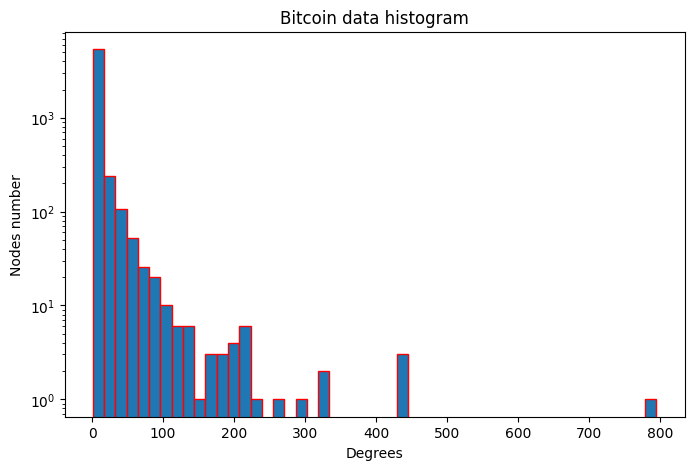

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

file = 'soc-sign-bitcoinotc.csv'
G = nx.read_edgelist(file, delimiter=',', data=[('rating', float), ('time', float)]) 

print(f"Number of nodes: {G.number_of_nodes()}, Number of edges: {G.number_of_edges()}")

# degrees of nodes
degrees = [degree for node, degree in G.degree()]

# histogram
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=50, edgecolor='red') 
plt.title("Bitcoin data histogram")
plt.xlabel("Degrees")
plt.ylabel("Nodes number")
plt.yscale('log') 

plt.show()

In [10]:
# analysis
components = list(nx.connected_components(G))
l_component_nodes = max(components, key=len)

G_largest = G.subgraph(l_component_nodes)
print(f"Number of nodes in largest component: {G_largest.number_of_nodes()}")

# average shortest path length
avg_path_length = nx.average_shortest_path_length(G_largest)
print(f"Average shortest path length: {avg_path_length}")

# average clustering coefficient
avg_clustering_coe = nx.average_clustering(G)
print(f"Average clustering coefficient: {avg_clustering_coe}")

Number of nodes in largest component: 5875
Average shortest path length: 3.5710878230065415
Average clustering coefficient: 0.17750449405289492


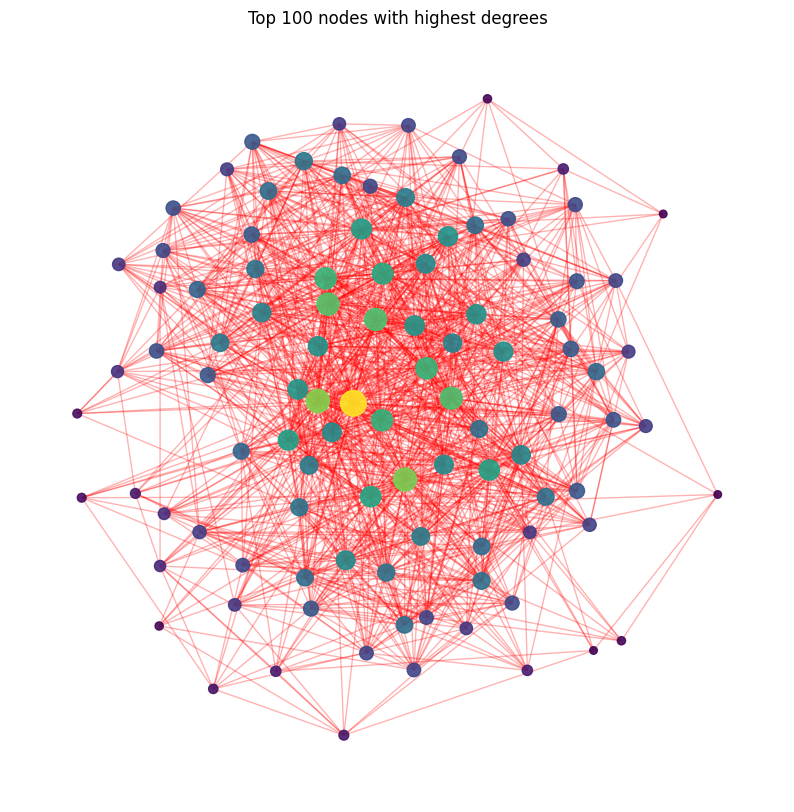

In [12]:
# 100 nodes with highest degrees
sorted_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)
top_100_nodes = [node for node, degree in sorted_nodes[:100]]
G_top = G.subgraph(top_100_nodes)

# nodes sizes and colors depending on the number of degrees
node_sizes = [G_top.degree(node) * 5 for node in G_top.nodes()]
node_colors = [G_top.degree(node) for node in G_top.nodes()]

# graph
plt.figure(figsize=(10, 10))
# kamada_kawai layout
pos = nx.kamada_kawai_layout(G_top)
nx.draw_networkx_nodes(G_top, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.viridis, alpha=0.9)
nx.draw_networkx_edges(G_top, pos, alpha=0.3, edge_color='red')
plt.title("Top 100 nodes with highest degrees")
plt.axis('off') 
plt.show()